In [21]:
## conda activate gpy_torch_env
import torch 
from torch.autograd.functional import jacobian
from torch.distributions.multivariate_normal import MultivariateNormal
import gpytorch
import pyro
from pyro.infer import MCMC, NUTS
import pyro.distributions as dist
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy import interpolate
from scipy.stats import norm, multivariate_normal, invgamma, uniform


## Forward Model

The susceptible-infected-recovered (SIR) model is a system of nonlinear ODEs given by
\begin{align}
    \frac{dS}{dt} &= \mu N - \mu S - \gamma I S \\
    \frac{dI}{dt} &=  \gamma I S - (r+\mu)I \\
    \frac{dR}{dt} &= r I - \mu R.
    \end{align}

where $\gamma$ is the infection rate, $r$ is the recovery rate, and $mu$ represents the collective birth and death rate. Each parameter is assumed to take values in the interval [0,1]. Assume that $\bm{\theta}$ are the model parameters and that the ODE system can be written more generally as $\dot{\bm{y}} = g(t,\bm{y};\bm{\theta})$.

Here, for numerical reasons, we provide the relative populations $S^*=S/N$, $I^*=I/N$, and $R^*=R/N$. The parameters are also log-transformed so that biologically relevant parameter values close to 0 can be sampled appropriately during MCMC.


We require the solution of the sensitivity system:
\begin{align}
    \frac{d\chi}{dt} &= \frac{\partial g}{\partial y} \frac{\partial y}{\partial \theta} + \frac{\partial g}{\partial \theta} \\
    &= \frac{\partial g}{\partial u} \chi + \frac{\partial g}{\partial \theta}
    \end{align}
where $\frac{\partial g}{\partial u}$ is the Jacobian of the system, $\bm{\chi}$ is the sensitivity of the states with respect to the parameters, and $\frac{\partial g}{\partial \bm{\theta}}$ are the derivatives with respect to the right hand side expressions. Again for numerical purposes we construct the relative variables for our system, i.e. scaled by the population $N$.

In [22]:
def coupled_sys(yall,t,params,N):
    # 3 states and 3x3=9 sensitivities
    S,I,R,Smu,Imu,Rmu,Sg,Ig,Rg,Sr,Ir,Rr = yall
    sens = yall[3:]
    # Unpack parameters
    mu,gamma,r = np.exp(params)
    # Jacobian of system
    dgdy = np.zeros((9,9))
    for i in range(3):
        ind = 3*i
        dgdy[ind,ind]   = -gamma*I - mu
        dgdy[ind,ind+1] = -gamma*S

        dgdy[ind+1,ind]   = gamma*I
        dgdy[ind+1,ind+1] = gamma*S - r - mu

        dgdy[ind+2,ind+1] = r
        dgdy[ind+2,ind+2] = -mu
        
    # Sensitivity vector should be column vector defined by dRhs1/dpar1, dRHS2/dpar1, dRHS3/dpar1, .... up to dRHS_N / dpar_N
    dgdpar = np.array([[N-S,-I,-R,-S*I,S*I,0,0,-I,I]])

    # RHS equations
    dSdt = mu*N - mu*S - gamma*I*S
    dIdt = gamma*I*S - (r + mu)*I
    dRdt = r*I - mu*R

    ds = np.matmul(dgdy,sens) + dgdpar

    dYall = np.zeros(12)
    dYall[0:3] = [dSdt,dIdt,dRdt]
    dYall[3:] = ds
    return dYall

def call_model(params,x):
    S0 = 9999
    I0 = 1
    R0 = 0
    N = S0+I0+R0
    X0 = [S0, I0, R0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]
    # Define the end time for the numerical solution and the time points
    tspace = x
    # Solve the system
    solution = odeint(coupled_sys, X0, tspace, args=(params.detach().numpy(), N))


    # Unpack solution and return model + sensitivities scaled by the total population
    S,I,R,Smu,Imu,Rmu,Sg,Ig,Rg,Sr,Ir,Rr = solution.T
    return torch.stack([torch.tensor(S),torch.tensor(I),torch.tensor(R),
                        torch.tensor(Smu),torch.tensor(Imu),torch.tensor(Rmu),
                        torch.tensor(Sg),torch.tensor(Ig),torch.tensor(Rg),
                        torch.tensor(Sr),torch.tensor(Ir),torch.tensor(Rr)])/N


<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\g'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\g'
C:\Users\colebanm\AppData\Local\Temp\ipykernel_11516\495025538.py:28: SyntaxWarning: invalid escape sequence '\m'
  ax[0,1].set_ylabel('$\mu$ sensitivity')
C:\Users\colebanm\AppData\Local\Temp\ipykernel_11516\495025538.py:36: SyntaxWarning: invalid escape sequence '\g'
  ax[1,0].set_ylabel('$\gamma$ sensitivity')


[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]


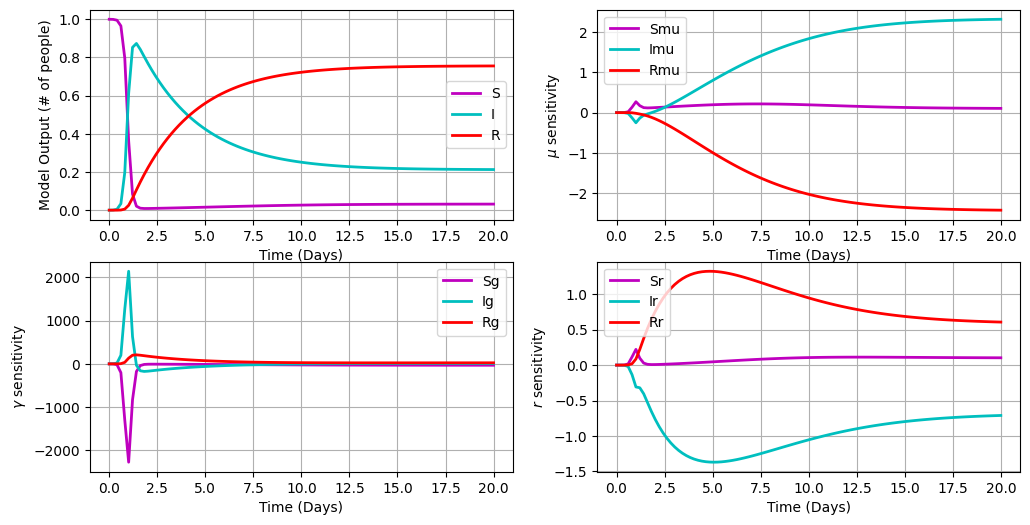

In [23]:
## design variables 
n_grid = 100
x = torch.linspace(0.0,20,n_grid)

## true parameter 
theta_true = torch.tensor(np.log([0.07, 0.001, 0.25]), requires_grad=False)

true_sol = call_model(theta_true,x)

S,I,R,Smu,Imu,Rmu,Sg,Ig,Rg,Sr,Ir,Rr = true_sol

# Plotting routine
f, ax = plt.subplots(2,2,figsize=(12,6))
print(ax)
ax[0,0].plot(x, S.detach().T, '-m', linewidth=2, label='S')
ax[0,0].plot(x, I.detach().T, '-c', linewidth=2, label='I')
ax[0,0].plot(x, R.detach().T, '-r', linewidth=2, label='R')
ax[0,0].legend()
ax[0,0].grid()
ax[0,0].set_ylabel('Model Output (# of people)')
ax[0,0].set_xlabel('Time (Days)')

ax[0,1].plot(x, Smu.detach().T, '-m', linewidth=2, label='Smu')
ax[0,1].plot(x, Imu.detach().T, '-c', linewidth=2, label='Imu')
ax[0,1].plot(x, Rmu.detach().T, '-r', linewidth=2, label='Rmu')
ax[0,1].legend()
ax[0,1].grid()
ax[0,1].set_ylabel('$\mu$ sensitivity')
ax[0,1].set_xlabel('Time (Days)')

ax[1,0].plot(x, Sg.detach().T, '-m', linewidth=2, label='Sg')
ax[1,0].plot(x, Ig.detach().T, '-c', linewidth=2, label='Ig')
ax[1,0].plot(x, Rg.detach().T, '-r', linewidth=2, label='Rg')
ax[1,0].legend()
ax[1,0].grid()
ax[1,0].set_ylabel('$\gamma$ sensitivity')
ax[1,0].set_xlabel('Time (Days)')

ax[1,1].plot(x, Sr.detach().T, '-m', linewidth=2, label='Sr')
ax[1,1].plot(x, Ir.detach().T, '-c', linewidth=2, label='Ir')
ax[1,1].plot(x, Rr.detach().T, '-r', linewidth=2, label='Rr')
ax[1,1].legend()
ax[1,1].grid()
ax[1,1].set_ylabel('$r$ sensitivity')
ax[1,1].set_xlabel('Time (Days)')

plt.show()


# Multivariate Orthogonal GP

In [24]:
def computeJitter(Cmat, target_min_eigval, min_jitter):
    eigvals = torch.linalg.eigvalsh(Cmat)
    lambda_min = eigvals.min()
    required_jitter = torch.clamp(target_min_eigval - lambda_min, min=min_jitter).item()
    return required_jitter  

def compute_jacobian(theta,x):
        # Break Jacobian into numerical solution of system 
        S,I,R,Smu,Imu,Rmu,Sg,Ig,Rg,Sr,Ir,Rr  = call_model(theta,x)
        # f1,f2,s11,s21,s12,s22 = solution.T
        # print(np.size(Smu,axis=0))
        jac = torch.empty(np.size(Smu,axis=0),3,3)
        jac[:,0,0] = Smu
        jac[:,0,1] = Sg
        jac[:,0,2] = Sr
        jac[:,1,0] = Imu
        jac[:,1,1] = Ig
        jac[:,1,2] = Ir
        jac[:,2,0] = Rmu
        jac[:,2,1] = Rg
        jac[:,2,2] = Rr
        return jac    

class MultivariateOrthogonalKernel(torch.nn.Module):
    def __init__(self, C_func, call_model, gamma=1e-1, target_min_eigval=None, min_jitter=1e-10):
        super().__init__()
        self.J = C_func.num_tasks
        self.C_func = C_func
        # self.fmodel = fmodel
        self.fmodel = call_model
        self.gamma = gamma
        self.target_min_eigval = target_min_eigval
        self.min_jitter = min_jitter
    
    def forward(self, x, theta, xvol=None):
        n = len(x)
        if not xvol:
            xvol = 1./n
        C_x = self.gamma*self.C_func(x).evaluate().view(n, self.J, n, self.J).permute(0, 2, 1, 3) 
        
        J_theta_x = compute_jacobian(theta,x)#jacobian(lambda th: self.fmodel(x, th), theta) ## n x J x P
        h_theta_x_trans = xvol*torch.sum(torch.matmul(C_x, J_theta_x.unsqueeze(0)),dim=1)
        H_theta_inv = torch.linalg.inv(xvol*xvol*torch.sum(torch.matmul(J_theta_x.permute(0, 2, 1).unsqueeze(1), 
                                                   torch.matmul(C_x, J_theta_x.unsqueeze(0))),
                                        dim=(0, 1)))
        C_delta_x = C_x - torch.einsum("aip,pq,bjq->abij", h_theta_x_trans, H_theta_inv, h_theta_x_trans)
        C_delta_x_flat = C_delta_x.permute(0, 2, 1, 3).reshape(n * J, n * J)
        C_delta_x_flat = (C_delta_x_flat + C_delta_x_flat.T)/2.
        ##note, einsum implements
        #for i1 in range(n):
        #    for i2 in range(n):
        #        [i1, i2, ...] = h_theta_x_trans[i1,...] @ H_theta @ h_theta_x_trans[i2,...].T
        ## add jitter for numerical stabalization 
        if self.target_min_eigval:
            required_jitter = computeJitter(C_delta_x_flat, self.target_min_eigval, self.min_jitter)
            C_delta_x_flat = C_delta_x_flat + required_jitter * torch.eye(n*J)
        return C_delta_x_flat

In [25]:
## define orthogonal discrepancy prior 
J = 3
gamma_true = 0.01 
bw_param_true = 8
marg_kernel = gpytorch.kernels.RBFKernel()
marg_kernel.lengthscale = torch.tensor(bw_param_true)
marg_kernel.raw_lengthscale.requires_grad = False
## numerical stability 
target_min_eigval = 1e-6
min_jitter = 1e-10 

Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
Cov_delta_theta = MultivariateOrthogonalKernel(Cov_unc, call_model, gamma=gamma_true, 
                                                    target_min_eigval=target_min_eigval, min_jitter=min_jitter)
C_delta_theta_true_xobs_flat = Cov_delta_theta(x, theta_true)

delta_ortho_theta_true_prior = MultivariateNormal(torch.zeros(n_grid * J), C_delta_theta_true_xobs_flat)

## add jitter for numerical stabality in unconstrained case
C_x_flat = gamma_true*Cov_unc(x).evaluate()
jitter = computeJitter(C_x_flat, target_min_eigval, min_jitter)
C_x_flat = C_x_flat + jitter*torch.eye(n_grid*J)
delta_unconstr_prior = MultivariateNormal(torch.zeros(n_grid * J), C_x_flat)
                                                                                  

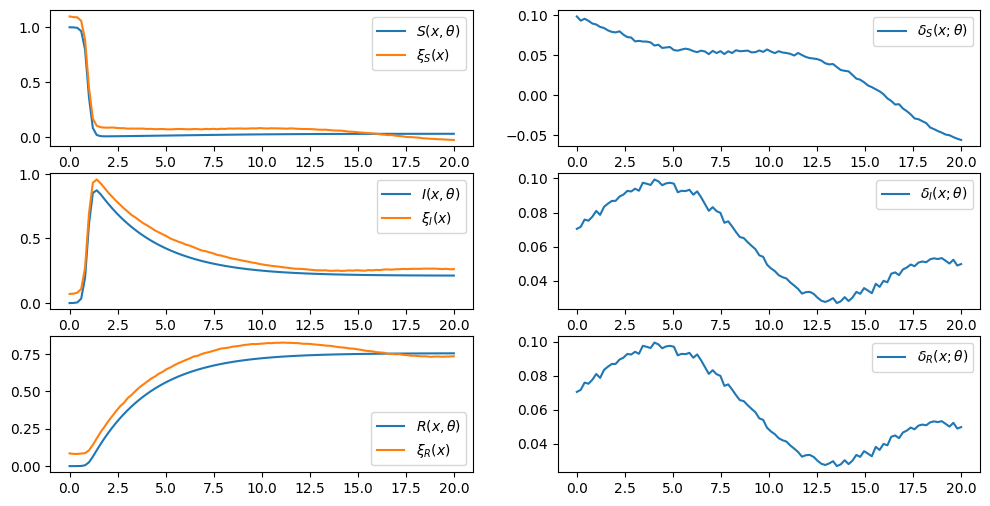

In [26]:
torch.manual_seed(444)
## Defined the true phyiscal process 
S,I,R,Smu,Imu,Rmu,Sg,Ig,Rg,Sr,Ir,Rr  = call_model(theta_true,x)
f_true = torch.transpose(torch.reshape(torch.concat([S,I,R]),(3,100)),0,1)

## TWO APPROACHES HERE
# Use the MOP as the discrepancy
## sample true discrepancy
delta_disc_true = delta_ortho_theta_true_prior.rsample((1,)).view(n_grid, J)
xi_true = f_true + delta_disc_true

# Or, instead, make discrepancy a sine function
# delta_disc_true = 0.1*np.sin(0.1*x.numpy())
# xi_true[:,0] = f_true[:,0] + delta_disc_true
# xi_true[:,1] = f_true[:,1] + delta_disc_true
# xi_true[:,2] = f_true[:,2] + delta_disc_true

## plot optimally calibrated model + true phyiscal process, 
fig, ax = plt.subplots(3,2,figsize=(12,6))

ax[0,0].plot(x.numpy(), f_true[:, 0].detach().numpy(), label=r'$S(x,\theta)$')
ax[0,0].plot(x.numpy(), xi_true[:, 0].detach().numpy(), label=r'$\xi_S(x)$')
ax[1,0].plot(x.numpy(), f_true[:, 1].detach().numpy(), label=r'$I(x,\theta)$')
ax[1,0].plot(x.numpy(), xi_true[:, 1].detach().numpy(), label=r'$\xi_I(x)$')
ax[2,0].plot(x.numpy(), f_true[:, 2].detach().numpy(), label=r'$R(x,\theta)$')
ax[2,0].plot(x.numpy(), xi_true[:, 2].detach().numpy(), label=r'$\xi_R(x)$')

ax[0,1].plot(x.numpy(), delta_disc_true[:, 0].detach().numpy(), label=r'$\delta_S(x; \theta)$')
ax[1,1].plot(x.numpy(), delta_disc_true[:, 1].detach().numpy(), label=r'$\delta_I(x; \theta)$')
ax[2,1].plot(x.numpy(), delta_disc_true[:, 1].detach().numpy(), label=r'$\delta_R(x; \theta)$')

ax[0,0].legend()
ax[1,0].legend()
ax[2,0].legend()
ax[0,1].legend()
ax[1,1].legend()
ax[2,1].legend()

# Statistical Inference

In [27]:
## observation model 
n_obs = 20
x_obs = torch.linspace(0.0, x[-1], n_obs)

## local interpolation from discretized function repreresentation
xi_1_interp = interpolate.interp1d(x.detach().numpy(), xi_true[:,0].detach().numpy())
xi_2_interp = interpolate.interp1d(x.detach().numpy(), xi_true[:,1].detach().numpy())
xi_3_interp = interpolate.interp1d(x.detach().numpy(), xi_true[:,2].detach().numpy())

xi_obs = torch.cat((torch.from_numpy(xi_1_interp(x_obs.detach().numpy())).float().view(-1,1),
                    torch.from_numpy(xi_2_interp(x_obs.detach().numpy())).float().view(-1,1),
                    torch.from_numpy(xi_3_interp(x_obs.detach().numpy())).float().view(-1,1)),
                    dim=-1)

## iid measurement error 
sigma_e = 0.01
y_obs = xi_obs + torch.normal(0, sigma_e, size=(n_obs,3))

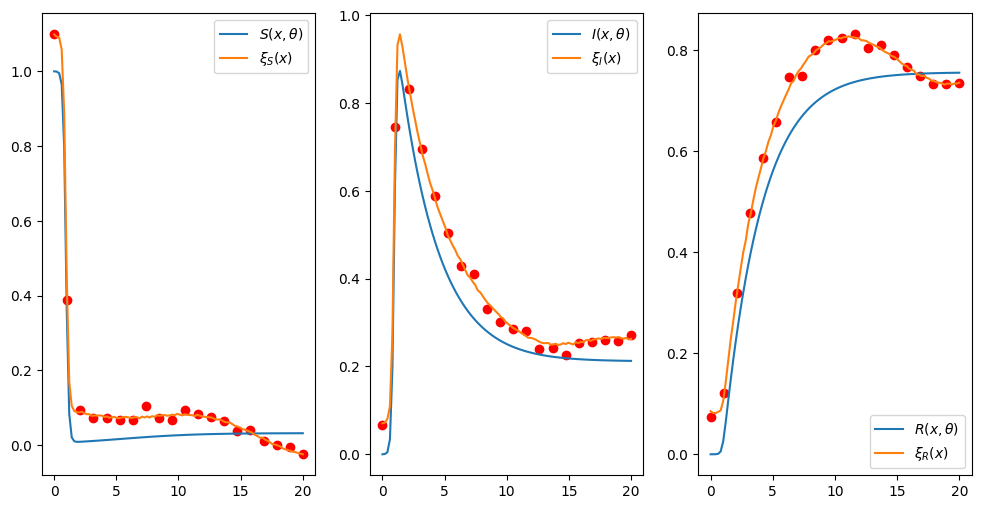

In [28]:
## plot optimally calibrated model + true phyiscal process, 
fig, ax = plt.subplots(1,3,figsize=(12,6))

ax[0].plot(x.numpy(), f_true[:, 0].detach().numpy(), label=r'$S(x,\theta)$')
ax[0].plot(x.numpy(), xi_true[:, 0].detach().numpy(), label=r'$\xi_S(x)$')
ax[0].scatter(x_obs.numpy(), y_obs[:, 0].detach().numpy(), c="r")

ax[1].plot(x.numpy(), f_true[:, 1].detach().numpy(), label=r'$I(x,\theta)$')
ax[1].plot(x.numpy(), xi_true[:, 1].detach().numpy(), label=r'$\xi_I(x)$')
ax[1].scatter(x_obs.numpy(), y_obs[:, 1].detach().numpy(), c="r")

ax[2].plot(x.numpy(), f_true[:, 2].detach().numpy(), label=r'$R(x,\theta)$')
ax[2].plot(x.numpy(), xi_true[:, 2].detach().numpy(), label=r'$\xi_R(x)$')
ax[2].scatter(x_obs.numpy(), y_obs[:, 2].detach().numpy(), c="r")


ax[0].legend()
ax[1].legend()
ax[2].legend()

In [29]:
# Try defining an update-able discrepancy
target_min_eigval = 1e-6
min_jitter = 1e-10 
marg_kernel = gpytorch.kernels.RBFKernel()
marg_kernel.initialize(lengthscale=torch.tensor(bw_param_true))
marg_kernel.raw_lengthscale.requires_grad = False   # freeze it if needed
GP_Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
GP_Cov_unc.data_covar_module.initialize(lengthscale=torch.tensor(bw_param_true))
GP_Cov_unc.data_covar_module.raw_lengthscale.requires_grad = False
GP_Cov_MOP = MultivariateOrthogonalKernel(Cov_unc, call_model, gamma=gamma_true, 
                                                target_min_eigval=target_min_eigval, min_jitter=min_jitter)
## inference

# Requires that you pass in simulator parameters, GP discrepancy parameters, the covariance kernel, and the measurement error variance
def potential_fn_MOP(theta,GPtheta,GP_cov,s2):
    # Gaussian Process for discrepancy term
    gamma,bw = GPtheta
    GP_cov.C_func.data_covar_module.raw_lengthscale.copy_(torch.tensor([bw]))
    GP_cov.gamma = gamma
    # Gaussian Process for discrepancy term
    C_delta_theta_true_xobs_flat = GP_cov(x_obs, theta)
    Cov = C_delta_theta_true_xobs_flat + (s2)*torch.eye(n_obs*J)
    # forward model 
    y_all = call_model(theta,x_obs)
    states = torch.transpose(torch.reshape(y_all[0:3,:],(3,len(x_obs))),0,1)
    f_x_flat = states.reshape(n_obs*J)

    ## posterior density (MJC: added try statement here because I kept getting non-SPD covariances)
    try:
       post_density = dist.MultivariateNormal(f_x_flat, Cov)
       PD_value = post_density.log_prob(y_obs.view(n_obs*J)) # EQ 17 IN OUR METHODS
       SS = torch.sum((y_obs.view(n_obs*J)-f_x_flat)**2)
    except:
       PD_value = torch.tensor(-torch.inf)
       SS = torch.inf
    return PD_value, SS



GPtheta = torch.tensor([0.1,1])
potential_fn_MOP(theta_true,GPtheta,GP_Cov_MOP,sigma_e**2)

(tensor(55.3881, grad_fn=<SubBackward0>), tensor(0.2613, dtype=torch.float64))

In [30]:

# Independent GPs for the discrepancy (KO style
def potential_fn_IND(theta,GPtheta,GP_cov,s2):
    # Gaussian Process for discrepancy term
    # Gaussian Process for discrepancy term
    gamma,bw = GPtheta
    GP_cov.data_covar_module.raw_lengthscale.copy_(torch.tensor([bw]))

    # Gaussian Process for discrepancy term
    Cov = gamma*Cov_unc(x_obs).evaluate() + (s2)*torch.eye(n_obs*J)
    ## forward model 
    # f_x_flat = fmodel_MJC(x_obs, theta).view(n_obs*J)
    y_all = call_model(theta,x_obs)
    states = torch.transpose(torch.reshape(y_all[0:3,:],(3,len(x_obs))),0,1)
    f_x_flat = states.reshape(n_obs*J)
    # print(f_x_flat)
    ## posterior density 
    post_density = dist.MultivariateNormal(f_x_flat, Cov)
    SS = torch.sum((y_obs.view(n_obs*J)-f_x_flat)**2)
    return post_density.log_prob(y_obs.view(n_obs*J)), SS
    
GPtheta = torch.tensor([0.1,1])
potential_fn_IND(theta_true,GPtheta,GP_Cov_unc,sigma_e**2)

(tensor(49.6891, grad_fn=<SubBackward0>), tensor(0.2613, dtype=torch.float64))

In [31]:
# y_all = call_model(theta_true,x_obs)
# states = torch.transpose(torch.reshape(y_all[0:3,:],(3,len(x_obs))),0,1)
# f_x_flat = states.reshape(n_obs*J)
# y_flat = y_obs.view(n_obs*J)

# C_delta_theta_true_xobs_flat = Cov_delta_theta(x_obs, theta_true)
# Cov = C_delta_theta_true_xobs_flat + (sigma_e**2)*torch.eye(n_obs*J)
# post_density = dist.MultivariateNormal(f_x_flat, Cov)
# PD_value = post_density.log_prob(y_obs.view(n_obs*J))
# print(post_density)
# print(PD_value)
# plt.figure()
# plt.plot(f_x_flat)
# plt.plot(y_flat)
# plt.show()


In [32]:
def adaptive_metropolis(post_func, data, theta0, s20, k0, M, covar, UB, LB, GP_cov):
    # Note: I removed the prior from this because we have uniform priors on theta and fixed discrepancy
    n_par = len(theta0)
    chain = torch.zeros((n_par, M))
    lik_chain = torch.zeros(M,1)
    s2chain = torch.zeros(M,1)
    n_y = len(data)
    print(n_y)

    if covar is None or len(covar) == 0:
        covar = torch.eye(n_par) * 0.1 * torch.abs(theta0)
    
    def lik_func(theta,thetaGP,s2):
        return post_func(theta,thetaGP,GP_cov,s2)
    
    chain[:, 0] = theta0
    thetamodel = theta0[:n_par-2]
    thetaGP    = np.exp(theta0[n_par-2:])
    lik_old, ss_old = lik_func(thetamodel,thetaGP,s20)
    sig_s = ss_old / (n_y - n_par)  # Estimate of error variance
    R = torch.linalg.cholesky(covar)
    print(thetamodel,thetaGP,ss_old,sig_s)


    # Error variance hyperparameters
    n_s = 0.01  # For inverse gamma
    aval = 0.5 * (n_s + n_y)  # This is constant
    bval = 0.5 * (n_s * sig_s + ss_old)
    s2chain[0] = invgamma.rvs(aval, scale=bval)
    # print(s2chain[0])
    # Initialize covariance estimates
    Vk = covar
    theta_bar = theta0
    Ip = torch.eye(n_par) * 1e-12  # Small jitter on diagonal for stability
    sp_cov = (2.38 ** 2) / n_par

    num_acc = 0
    prob_acc = np.log(uniform.rvs(size=M))
    for i in range(1, M):
        # given discrepancy value previously, compute log-likelihood with covariance given by
        # the MOP approach
        theta_star = chain[:, i - 1] + R.T.detach() @ np.random.normal(0, 1, n_par)

        if torch.sum(theta_star>UB).detach()>0 or torch.sum(theta_star<LB).detach()>0:
            lik_star = torch.inf
            acc_prob = -torch.inf
            ss_star = torch.inf
        else:
            thetamodel = theta_star[0:n_par-2]
            thetaGP    = np.exp(theta_star[n_par-2:])
            lik_old, ss_old   = lik_func(chain[0:n_par-2,i-1],np.exp(chain[n_par-2:,i-1]),s2chain[i-1])
            lik_star, ss_star = lik_func(thetamodel,thetaGP,s2chain[i-1])
            # if torch.abs(lik_star)>1e10:
                # acc_prob = 0.0
            # else:
            acc_prob = (lik_star) - (lik_old)
              # Recompute for the same s2 value
        
        
        if acc_prob > prob_acc[i]:
            ss_old = ss_star
            chain[:, i] = theta_star
            lik_old = lik_star
            num_acc += 1
        else:
            chain[:, i] = chain[:, i - 1]
            
        lik_chain[i]=lik_old

        # Gibbs step on hyperparameter
        bval = 0.5 * (n_s * sig_s + ss_old)
        s2chain[i] = np.minimum(invgamma.rvs(aval, scale=bval),1e4)
        # print(acc_prob,prob_acc[i],s2chain[i])

        if i % 500 == 0:
            print('Percent done:',i/M*100)
            print('Acceptance rate:')
            print((num_acc / i) * 100)
        # Update covariance and mean parameter
        theta_bar_old = theta_bar
        theta_bar = (i / (i + 1)) * theta_bar_old + chain[:, i] / (i + 1)
        Vk = ((i - 1) * Vk / i + (sp_cov / i) * (i * torch.outer(theta_bar_old, theta_bar_old) -
             (i + 1) * torch.outer(theta_bar, theta_bar) + torch.outer(chain[:, i], chain[:, i]) + Ip))
        
        if i % k0 == 0:  # Update covariance in sampling
            Vk = 0.5*(Vk+Vk.T)+1e-12*np.eye(n_par)
            R = torch.linalg.cholesky(Vk)

    print('Acceptance rate:')
    print((num_acc / M) * 100)
    print(Vk)

    return chain, lik_chain, s2chain

In [33]:
LB = -20*torch.ones(len(theta_true))
UB = 0*torch.ones(len(theta_true))
UB = torch.cat((UB, torch.tensor([np.log(0.02), np.log(10)])))
LB = torch.cat((LB, torch.tensor([np.log(0.009), np.log(5)])))
theta_all_true = torch.cat((theta_true,torch.tensor([np.log(gamma_true),np.log(bw_param_true)])))
k0 = 1000 # make this less than M to actually make this the AM; otherwise its MH
M = 5000
covar = torch.eye(len(theta_all_true)) * 0.0001 * torch.abs(theta_all_true)
print(covar)


tensor([[0.0003, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0007, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0001, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0005, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0002]], dtype=torch.float64)


In [34]:
# Adaptive metropolis using KO independent discrepancy
chain_IND, lik_chain_IND, s2_IND = adaptive_metropolis(post_func=potential_fn_IND, data=y_obs.view(n_obs*J), theta0=theta_all_true, s20=sigma_e**2, k0=k0, M=M, covar=covar, UB=UB, LB=LB, GP_cov=GP_Cov_unc)

60
tensor([-2.6593, -6.9078, -1.3863], dtype=torch.float64) tensor([0.0100, 8.0000], dtype=torch.float64) tensor(0.2613, dtype=torch.float64) tensor(0.0048, dtype=torch.float64)


C:\Users\colebanm\AppData\Local\Temp\ipykernel_11516\1967601215.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  thetaGP    = np.exp(theta0[n_par-2:])
C:\Users\colebanm\AppData\Local\Temp\ipykernel_11516\1967601215.py:42: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  theta_star = chain[:, i - 1] + R.T.detach() @ np.random.normal(0, 1, n_par)
C:\Users\colebanm\AppData\Local\Temp\ipykernel_11516\1967601215.py:50: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  thetaGP    = np.exp(theta_star[n_par-2:])
C:\Users\colebanm\AppData\Local\Temp\ipykernel_11516\1967601215.py:51: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lik_old,

Percent done: 10.0
Acceptance rate:
71.8
Percent done: 20.0
Acceptance rate:
74.4


C:\Users\colebanm\AppData\Local\Temp\ipykernel_11516\1967601215.py:86: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Vk = 0.5*(Vk+Vk.T)+1e-12*np.eye(n_par)


Percent done: 30.0
Acceptance rate:
60.266666666666666
Percent done: 40.0
Acceptance rate:
53.5
Percent done: 50.0
Acceptance rate:
48.559999999999995
Percent done: 60.0
Acceptance rate:
46.33333333333333
Percent done: 70.0
Acceptance rate:
43.114285714285714
Percent done: 80.0
Acceptance rate:
42.75
Percent done: 90.0
Acceptance rate:
40.55555555555556
Acceptance rate:
38.019999999999996
tensor([[ 1.9349e+01, -5.0897e+00,  1.1111e+00, -1.2394e-01,  1.4086e-01],
        [-5.0897e+00,  4.2517e+00, -4.8902e-01,  9.0353e-02, -9.2456e-02],
        [ 1.1111e+00, -4.8902e-01,  1.4021e-01, -1.1228e-02,  1.5583e-02],
        [-1.2394e-01,  9.0353e-02, -1.1228e-02,  1.9947e-02, -1.5376e-03],
        [ 1.4086e-01, -9.2456e-02,  1.5583e-02, -1.5376e-03,  3.9089e-02]],
       dtype=torch.float64)


In [35]:
# Adaptive metropolis using MOP discrepancy
chain_MOP, lik_chain_MOP, s2_MOP = adaptive_metropolis(post_func=potential_fn_MOP, data=y_obs.view(n_obs*J), theta0=theta_all_true, s20=sigma_e**2, k0=k0, M=M, covar=covar, UB=UB, LB=LB, GP_cov=GP_Cov_MOP)

60
tensor([-2.6593, -6.9078, -1.3863], dtype=torch.float64) tensor([0.0100, 8.0000], dtype=torch.float64) tensor(0.2613, dtype=torch.float64) tensor(0.0048, dtype=torch.float64)


C:\Users\colebanm\AppData\Local\Temp\ipykernel_11516\1967601215.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  thetaGP    = np.exp(theta0[n_par-2:])
C:\Users\colebanm\AppData\Local\Temp\ipykernel_11516\1967601215.py:42: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  theta_star = chain[:, i - 1] + R.T.detach() @ np.random.normal(0, 1, n_par)
C:\Users\colebanm\AppData\Local\Temp\ipykernel_11516\1967601215.py:50: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  thetaGP    = np.exp(theta_star[n_par-2:])
C:\Users\colebanm\AppData\Local\Temp\ipykernel_11516\1967601215.py:51: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lik_old,

Percent done: 10.0
Acceptance rate:
62.4
Percent done: 20.0
Acceptance rate:
62.6


C:\Users\colebanm\AppData\Local\Temp\ipykernel_11516\1967601215.py:86: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Vk = 0.5*(Vk+Vk.T)+1e-12*np.eye(n_par)


Percent done: 30.0
Acceptance rate:
53.13333333333333
Percent done: 40.0
Acceptance rate:
50.55
Percent done: 50.0
Acceptance rate:
45.519999999999996
Percent done: 60.0
Acceptance rate:
41.266666666666666
Percent done: 70.0
Acceptance rate:
38.371428571428574
Percent done: 80.0
Acceptance rate:
36.825
Percent done: 90.0
Acceptance rate:
35.333333333333336
Acceptance rate:
34.300000000000004
tensor([[ 1.9491e-02,  2.7199e-04,  7.2940e-03,  3.2479e-03, -3.8494e-05],
        [ 2.7199e-04,  7.8085e-04,  1.0786e-04,  5.6319e-05, -1.5492e-04],
        [ 7.2940e-03,  1.0786e-04,  5.0326e-03,  1.7335e-03,  3.6074e-04],
        [ 3.2479e-03,  5.6319e-05,  1.7335e-03,  4.4379e-02,  3.1142e-03],
        [-3.8494e-05, -1.5492e-04,  3.6074e-04,  3.1142e-03,  2.2641e-02]],
       dtype=torch.float64)


tensor([-2.6593, -6.9078, -1.3863], dtype=torch.float64)


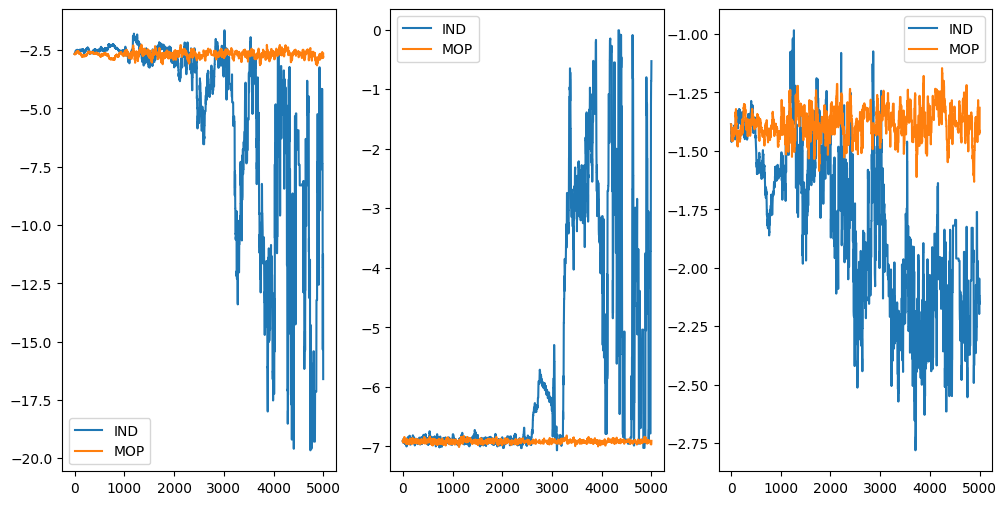

In [36]:
fig, ax = plt.subplots(1,3,figsize=(12,6))

ax[0].plot(chain_IND[0,:].detach(),label='IND')
ax[0].plot(chain_MOP[0,:].detach(),label='MOP')
ax[0].legend()

ax[1].plot(chain_IND[1,:].detach(),label='IND')
ax[1].plot(chain_MOP[1,:].detach(),label='MOP')
ax[1].legend()


ax[2].plot(chain_IND[2,:].detach(),label='IND')
ax[2].plot(chain_MOP[2,:].detach(),label='MOP')
ax[2].legend()
print(theta_true)

<>:7: SyntaxWarning: invalid escape sequence '\T'
<>:16: SyntaxWarning: invalid escape sequence '\T'
<>:24: SyntaxWarning: invalid escape sequence '\T'
<>:7: SyntaxWarning: invalid escape sequence '\T'
<>:16: SyntaxWarning: invalid escape sequence '\T'
<>:24: SyntaxWarning: invalid escape sequence '\T'
C:\Users\colebanm\AppData\Local\Temp\ipykernel_11516\2439726846.py:7: SyntaxWarning: invalid escape sequence '\T'
  plt.axvline(theta_true[0].detach(), color='red', linestyle='--', label='True $\Theta_1$')
C:\Users\colebanm\AppData\Local\Temp\ipykernel_11516\2439726846.py:16: SyntaxWarning: invalid escape sequence '\T'
  plt.axvline(theta_true[1].detach(), color='red', linestyle='--', label='True $\Theta_2$')
C:\Users\colebanm\AppData\Local\Temp\ipykernel_11516\2439726846.py:24: SyntaxWarning: invalid escape sequence '\T'
  plt.axvline(theta_true[2].detach(), color='red', linestyle='--', label='True $\Theta_2$')


(np.float64(1.5757325112819671),
 np.float64(2.3370867550373076),
 np.float64(0.0),
 np.float64(3.26901934587795))

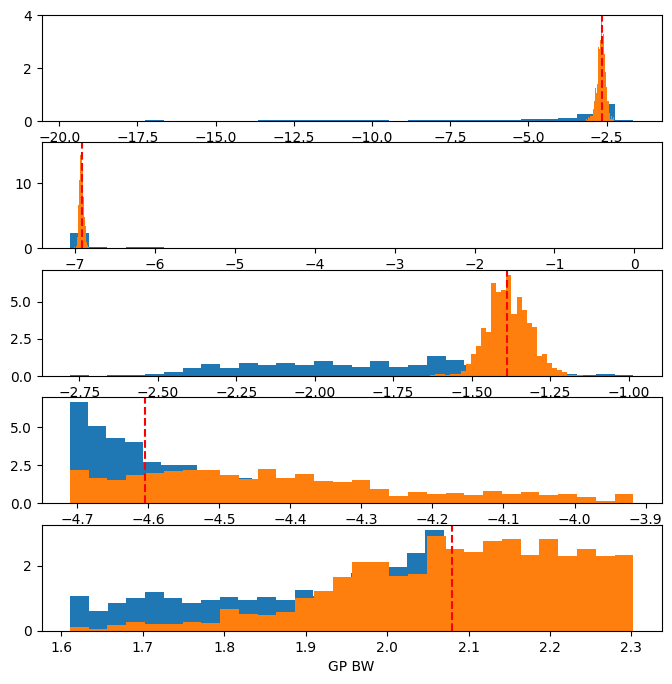

In [44]:
# Analyze the results
# Plot the results
plt.figure(figsize=(8, 8))
plt.subplot(5, 1, 1)
plt.hist(chain_IND[0,:].detach(), bins=30, density=True)
plt.hist(chain_MOP[0,:].detach(), bins=30, density=True)
plt.axvline(theta_true[0].detach(), color='red', linestyle='--', label='True $\Theta_1$')
# plt.xlim(param_ranges[:,0])
plt.xlabel(r'$\theta_1$')
plt.axis('tight')


plt.subplot(5, 1, 2)
plt.hist(chain_IND[1,:].detach(), bins=30, density=True)
plt.hist(chain_MOP[1,:].detach(), bins=30, density=True)
plt.axvline(theta_true[1].detach(), color='red', linestyle='--', label='True $\Theta_2$')
# plt.xlim(param_ranges[:,1])
plt.xlabel(r'$\theta_2$')
plt.axis('tight')

plt.subplot(5, 1, 3)
plt.hist(chain_IND[2,:].detach(), bins=30, density=True)
plt.hist(chain_MOP[2,:].detach(), bins=30, density=True)
plt.axvline(theta_true[2].detach(), color='red', linestyle='--', label='True $\Theta_2$')
# plt.xlim(param_ranges[:,2])
plt.xlabel(r'$\theta_3$')
plt.axis('tight')

plt.subplot(5, 1, 4)
plt.hist(chain_IND[3,:].detach(), bins=30, density=True)
plt.hist(chain_MOP[3,:].detach(), bins=30, density=True)
plt.axvline(np.log(gamma_true), color='red', linestyle='--', label='True GP scale')
# plt.xlim(param_ranges[:,2])
plt.xlabel('GP scale')
plt.axis('tight')

plt.subplot(5, 1, 5)
plt.hist(chain_IND[4,:].detach(), bins=30, density=True)
plt.hist(chain_MOP[4,:].detach(), bins=30, density=True)
plt.axvline(np.log(bw_param_true), color='red', linestyle='--', label='True GP bw')
# plt.xlim(param_ranges[:,2])
plt.xlabel('GP BW')
plt.axis('tight')
